# Cluster similarity with MetaNeighbor

In [1]:
%load_ext autoreload

In [2]:
import gc
import pickle
import os
import warnings
import pprint
from os.path import join, isfile
from IPython.display import display, Markdown

import anndata
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import pymn

## Load data

In [3]:
CACHE_DIR = "/vol/data/dataset-similarity/cache"
SAVE_DIR = "/vol/data/dataset-similarity/models/pyMN"
FIG_DIR = "/vol/data/dataset-similarity/figures/pyMN"

QUERY_DATASET = "7d7cabfd-1d1f-40af-96b7-26a0825a306d"
REF_DATASET = "ced320a1-29f3-47c1-a735-513c7084d508_CAP"

N_TOP_GENES = 3000

In [4]:
cache_file = join(
    CACHE_DIR, 
    "+".join([QUERY_DATASET, REF_DATASET, f"{N_TOP_GENES}HVGs"]) + ".pickle"
)
with open(cache_file, "rb") as f:
    adata_query, adata_ref = pickle.load(f)

In [5]:
adata_query

AnnData object with n_obs × n_vars = 600929 × 3000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'batch', 'ct1', 'ct2', 'ct3', 'cell_type_author', 'sample_id'
    var: 'feature_id'
    uns: 'de_res_ova', 'de_res_ava'
    obsm: 'X_scTab'

In [6]:
adata_ref

AnnData object with n_obs × n_vars = 1265624 × 3000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'sample_uuid', 'author_cell_type', 'cell_type_author', 'sample_id'
    var: 'feature_id'
    uns: 'de_res_ova', 'de_res_ava'
    obsm: 'X_scTab', 'X_scimilarity'

In [7]:
adata = anndata.concat(
    [adata_query, adata_ref], 
    label="dataset", 
    keys=["query", "ref"]
)
adata

AnnData object with n_obs × n_vars = 1866553 × 3000
    obs: 'assay', 'cell_type', 'development_stage', 'disease', 'donor_id', 'is_primary_data', 'sex', 'suspension_type', 'tissue', 'cell_type_author', 'sample_id', 'dataset'
    obsm: 'X_scTab'

In [8]:
# MetaNeighbor only works on dense data
adata.X = adata.X.toarray()
# MetaNeighbor does not work with categorical columns
adata.obs["dataset"] = adata.obs["dataset"].astype(str)
adata.obs["cell_type_author"] = adata.obs["cell_type_author"].astype(str)

In [9]:
pymn.variableGenes(adata, study_col="dataset")

## Run MetaNeighbor

In [10]:
pymn.MetaNeighborUS(
    adata,
    study_col="dataset",
    ct_col="cell_type_author",
    fast_version=True
)

In [11]:
mapping = adata.uns["MetaNeighborUS"]
mapping = mapping.loc[
    mapping.index.str.startswith("query"),
    mapping.columns.str.startswith("ref")
]
mapping.index = mapping.index.str.removeprefix("query|")
mapping.columns = mapping.columns.str.removeprefix("ref|")

## Visualize cluster similarities

In [12]:
%autoreload
from datasim.plotting import plot_cluster_mapping

In [13]:
order_index = [
    'B_Mem',
    'B_Mem_Prolif',
    'B_Naive',
    'B_Preplasma',
    'NKT',
    'NK_CD16+',
    'NK_CD56++',
    'NK_Prolif',
    'PB',
    'PB_Prolif',
    'Progen_CLP',
    'Progen_CMP',
    'Progen_MEP',
    'Progen_MPP',
    'T4_Mem',
    'T4_Mem_Prolif',
    'T4_Naive',
    'T4_Treg',
    'T8_MAIT',
    'T8_Mem',
    'T8_Mem_Prolif',
    'T8_Naive',
    'T_NK_Prolif',
    'Tgd_1',
    'Tgd_2',
    'cDC_1',
    'cDC_2',
    'pDC',
    'cM',
    'ncM',
]

In [14]:
order_columns = [
    'memory_B',
    'memory_B_IGHMhi',
    'memory_B_IGHMlo',
    'naive_B',
    'atypical_B',
    'B_unknown',
    'NK',
    'CD16+_NK',
    'CD56+_NK',
    'Plasma_Cell',
    'Platelet',
    'CD34_HSPC',
    'CD4+_T',
    'CD4+_T_cm',
    'CD4+_T_cyt',
    'CD4+_T_em',
    'CD4+_T_naive',
    'Treg',
    'CD8+_T_GZMBhi',
    'CD8+_T_GZMKhi',
    'CD8+_T_naive',
    'CD8+_T_unknown',
    'MAIT',
    'dnT',
    'gdT_GZMBhi',
    'gdT_GZMKhi',
    'T_unknown',
    'cDC1',
    'cDC2',
    'DC_SIGLEC6hi',
    'pDC',
    'Myeloid',
    'CD14+_Monocyte',
    'CD16+_Monocyte',
    'ILC',
]

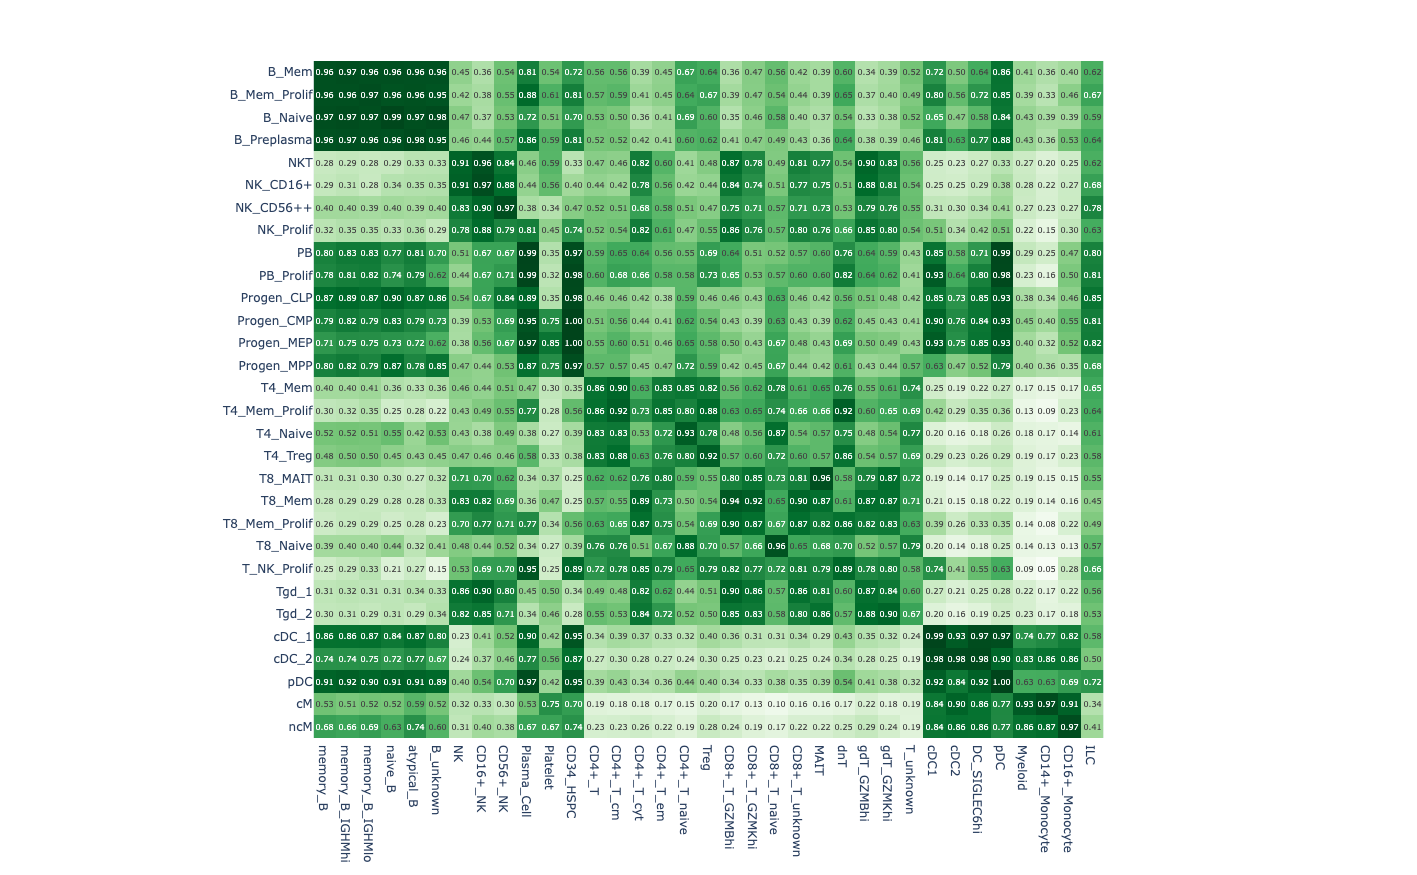

In [15]:
# import scipy.cluster.hierarchy as sch

# row_linkage = sch.linkage(mapping, method="average", metric="euclidean")
# col_linkage = sch.linkage(mapping.T, method="average", metric="euclidean")

# row_order = sch.leaves_list(row_linkage)
# col_order = sch.leaves_list(col_linkage)

fig = plot_cluster_mapping(mapping.loc[order_index, order_columns], show=False, sort_by_score=False)
fig.update_layout(coloraxis_showscale=False)

In [16]:
mapping.to_parquet("pyMN_mapping.parquet")

In [17]:
fig.write_image("plots/pyMN-immune-example.svg")

In [18]:
top_hits_mn = pymn.topHits(adata, save_uns=False)

ind = top_hits_mn["Study_ID|Celltype_1"].str.startswith("ref|")
top_hits_mn.loc[ind, "Study_ID|Celltype_1"], top_hits_mn.loc[ind, "Study_ID|Celltype_2"] = (
    top_hits_mn.loc[ind, "Study_ID|Celltype_2"], top_hits_mn.loc[ind, "Study_ID|Celltype_1"]
)
top_hits_mn["Study_ID|Celltype_1"] = top_hits_mn["Study_ID|Celltype_1"].str.removeprefix("query|")
top_hits_mn["Study_ID|Celltype_2"] = top_hits_mn["Study_ID|Celltype_2"].str.removeprefix("ref|")


top_hits_mn = (
    top_hits_mn[["Study_ID|Celltype_1", "Study_ID|Celltype_2"]]
    .groupby("Study_ID|Celltype_1")
    ["Study_ID|Celltype_2"].unique().map(list)
    .to_dict()
)


summaries = []
for i, k in enumerate(mapping.index):
    v = top_hits_mn.get(k, [])
    summaries.append(f"*{i+1}*: **{k}**: {v} <br>")

display(Markdown("".join(summaries)))    

*1*: **B_Mem**: ['memory_B_IGHMhi'] <br>*2*: **B_Mem_Prolif**: ['memory_B_IGHMlo'] <br>*3*: **B_Naive**: ['naive_B', 'B_unknown', 'memory_B_IGHMhi', 'memory_B'] <br>*4*: **B_Preplasma**: ['atypical_B'] <br>*5*: **NKT**: ['CD16+_NK'] <br>*6*: **NK_CD16+**: ['CD16+_NK'] <br>*7*: **NK_CD56++**: ['CD56+_NK'] <br>*8*: **NK_Prolif**: [] <br>*9*: **PB**: ['Plasma_Cell'] <br>*10*: **PB_Prolif**: ['Plasma_Cell'] <br>*11*: **Progen_CLP**: ['CD34_HSPC'] <br>*12*: **Progen_CMP**: ['CD34_HSPC'] <br>*13*: **Progen_MEP**: ['CD34_HSPC'] <br>*14*: **Progen_MPP**: ['CD34_HSPC'] <br>*15*: **T4_Mem**: [] <br>*16*: **T4_Mem_Prolif**: [] <br>*17*: **T4_Naive**: [] <br>*18*: **T4_Treg**: [] <br>*19*: **T8_MAIT**: ['MAIT'] <br>*20*: **T8_Mem**: [] <br>*21*: **T8_Mem_Prolif**: [] <br>*22*: **T8_Naive**: ['CD8+_T_naive'] <br>*23*: **T_NK_Prolif**: [] <br>*24*: **Tgd_1**: [] <br>*25*: **Tgd_2**: [] <br>*26*: **cDC_1**: ['cDC1'] <br>*27*: **cDC_2**: ['DC_SIGLEC6hi', 'cDC2'] <br>*28*: **cM**: ['CD14+_Monocyte'] <br>*29*: **ncM**: ['CD16+_Monocyte'] <br>*30*: **pDC**: ['pDC'] <br>

In [19]:
top_hits_mn = pymn.topHits(adata, save_uns=False, threshold=0.9)

ind = top_hits_mn["Study_ID|Celltype_1"].str.startswith("ref|")
top_hits_mn.loc[ind, "Study_ID|Celltype_1"], top_hits_mn.loc[ind, "Study_ID|Celltype_2"] = (
    top_hits_mn.loc[ind, "Study_ID|Celltype_2"], top_hits_mn.loc[ind, "Study_ID|Celltype_1"]
)
top_hits_mn["Study_ID|Celltype_1"] = top_hits_mn["Study_ID|Celltype_1"].str.removeprefix("query|")
top_hits_mn["Study_ID|Celltype_2"] = top_hits_mn["Study_ID|Celltype_2"].str.removeprefix("ref|")


top_hits_mn = (
    top_hits_mn[["Study_ID|Celltype_1", "Study_ID|Celltype_2"]]
    .groupby("Study_ID|Celltype_1")
    ["Study_ID|Celltype_2"].unique().map(list)
    .to_dict()
)


summaries = []
for i, k in enumerate(mapping.index):
    v = top_hits_mn.get(k, [])
    summaries.append(f"*{i+1}*: **{k}**: {v} <br>")

display(Markdown("".join(summaries))) 

*1*: **B_Mem**: ['memory_B_IGHMhi'] <br>*2*: **B_Mem_Prolif**: ['memory_B_IGHMlo'] <br>*3*: **B_Naive**: ['naive_B', 'B_unknown', 'memory_B_IGHMhi', 'memory_B'] <br>*4*: **B_Preplasma**: ['atypical_B'] <br>*5*: **NKT**: ['CD16+_NK'] <br>*6*: **NK_CD16+**: ['CD16+_NK', 'NK'] <br>*7*: **NK_CD56++**: ['CD56+_NK'] <br>*8*: **NK_Prolif**: [] <br>*9*: **PB**: ['Plasma_Cell'] <br>*10*: **PB_Prolif**: ['Plasma_Cell'] <br>*11*: **Progen_CLP**: ['CD34_HSPC'] <br>*12*: **Progen_CMP**: ['CD34_HSPC'] <br>*13*: **Progen_MEP**: ['CD34_HSPC'] <br>*14*: **Progen_MPP**: ['CD34_HSPC'] <br>*15*: **T4_Mem**: ['CD4+_T_cm'] <br>*16*: **T4_Mem_Prolif**: ['dnT', 'CD4+_T_cm'] <br>*17*: **T4_Naive**: ['CD4+_T_naive'] <br>*18*: **T4_Treg**: ['Treg'] <br>*19*: **T8_MAIT**: ['MAIT'] <br>*20*: **T8_Mem**: ['CD8+_T_GZMBhi', 'CD8+_T_GZMKhi', 'CD8+_T_unknown'] <br>*21*: **T8_Mem_Prolif**: [] <br>*22*: **T8_Naive**: ['CD8+_T_naive'] <br>*23*: **T_NK_Prolif**: ['Plasma_Cell'] <br>*24*: **Tgd_1**: ['CD8+_T_GZMBhi'] <br>*25*: **Tgd_2**: ['gdT_GZMKhi'] <br>*26*: **cDC_1**: ['cDC1'] <br>*27*: **cDC_2**: ['DC_SIGLEC6hi', 'cDC2'] <br>*28*: **cM**: ['CD14+_Monocyte', 'Myeloid'] <br>*29*: **ncM**: ['CD16+_Monocyte'] <br>*30*: **pDC**: ['pDC'] <br>